# 🛒 Projeto Integrador — O Peso das Palavras - Análise Exploratória

**SENAI | AWS | Projeto Integrador Interdisciplinar**

---

Este projeto realiza uma análise exploratória de dados em avaliações de um marketplace de e-commerce, com o objetivo de investigar a relação entre as notas atribuídas pelos clientes e o conteúdo de texto de seus comentários. A análise busca identificar padrões de satisfação, tendências de comportamento e possíveis inconsistências entre a avaliação em numeros e o sentimento descrito nos textos, gerando gráficos que auxiliem na compreensão da experiência do consumidor e apoiem a tomada de decisões voltadas à melhoria da qualidade de produtos e serviços.

**Estrutura do projeto:**
- Seção 0 → Configuração do Ambiente (Instalações, imports e configurações)

- Seção 1 → Carregamento e diagnóstico do banco (Leitura do banco
Estrutura, tipos e qualidade dos dados)

- Seção 2 → Limpeza e tratamento dos dados(Tratamento de nulos, ajuste de tipos e padronizações)

- Seção 3 → Análise Exploratória das Avaliações(Distribuição das notas
Junção/concatenação dos comentários, primeiros insights)

- Seção 4 → Investigação da Coerência entre Nota e Comentário(Identificação do problema de inconsistência e casos divergentes)

- Seção 5 → Análise de sentimento (VADER, LeIA, Transformers)

- Seção 6 → Comparação entre modelos(Métricas, concordância entre resultados, escolha do modelo mais adequado)

- Seção 7 → Análise Textual Complementar (Emojis, frequência de palavras e Word Cloud)

- Seção 8 → Índice de confiabilidade por vendedor(Cálculo do índiceordenação, insights finais)


---
# Seção 0 — Instalações e Imports

Carregamento das bibliotecas e configurações necessárias para a execução de todas as etapas da análise.

In [ ]:
# ============================================================ #
# Instalação de pacotes externos
# ============================================================ #
!pip install -q vaderSentiment
!pip install -q leia-br
!pip install -q transformers torch
!pip install -q wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
# ============================================================ #
# Imports gerais
# ============================================================ #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import time
from wordcloud import WordCloud
from tqdm.auto import tqdm
from google.colab import drive

# ============================================================ #
# Imports de análise de sentimento
# ============================================================ #
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as VaderAnalyzer
from LeIA import SentimentIntensityAnalyzer as LeiaAnalyzer
from transformers import pipeline

# ============================================================ #
# Configurações visuais
# ============================================================ #
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

print('✅ Imports realizados com sucesso.')

✅ Imports realizados com sucesso.


---
## Funções Auxiliares

Todas as funções reutilizáveis do projeto estão definidas aqui — análise de DataFrame, tratamento de texto, classificação de sentimento e algoritmos de ordenação.

In [ ]:
# ============================================================ #
# Análise exploratória de DataFrames
# ============================================================ #
def analise_df(nome, df):
    print(f"\n{'='*55}")
    print(f"  TABELA: {nome}")
    print(f"{'='*55}")
    print("\n► HEAD")
    display(df.head())
    print("\n► INFO")
    df.info()
    print("\n► DESCRIBE")
    display(df.describe(include='all'))
    print("\n► NULOS POR COLUNA")
    display(df.isnull().sum()[df.isnull().sum() > 0])

# ============================================================ #
# Manipulação de texto
# ============================================================ #
def strip_accents(text):
    """Remove acentos de uma string."""
    if isinstance(text, str):
        text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    return text

def combine_review_text(row):
    """Concatena título e mensagem da avaliação, tratando nulos."""
    title_str  = str(row['review_comment_title'])   if pd.notna(row['review_comment_title'])   else ''
    message_str = str(row['review_comment_message']) if pd.notna(row['review_comment_message']) else ''
    if title_str and message_str:
        return f"{title_str} - {message_str}"
    return title_str or message_str or ''

# ============================================================ #
# Classificação de sentimento
# ============================================================ #
def classificacao(pontuacao):
    """Classifica pontuação contínua em categoria textual."""
    if pontuacao < -0.6:                        return 'muito negativo'
    elif -0.6 <= pontuacao < -0.2:              return 'negativo'
    elif -0.2 <= pontuacao < 0.2:               return 'neutro'
    elif  0.2 <= pontuacao < 0.6:               return 'positivo'
    else:                                        return 'muito positivo'

def classificacao_score(pontuacao):
    """Mapeia pontuação contínua para escala de 1 a 5 estrelas."""
    if pontuacao < -0.6:                        return 1
    elif -0.6 <= pontuacao < -0.2:              return 2
    elif -0.2 <= pontuacao < 0.2:               return 3
    elif  0.2 <= pontuacao < 0.6:               return 4
    else:                                        return 5

def get_sentiment_score_from_label(label):
    """Converte rótulo de estrelas do Transformer para score contínuo."""
    if '1 star'  in label: return -1.0
    elif '2 stars' in label: return -0.5
    elif '3 stars' in label: return  0.0
    elif '4 stars' in label: return  0.5
    else:                    return  1.0

# ============================================================ #
# Algoritmos de ordenação — Selection Sort
# ============================================================ #
def selection_sort_by_length(data):
    """Ordena lista de strings por comprimento (maior → menor) via Selection Sort."""
    sorted_data = list(data)
    n = len(sorted_data)
    for i in range(n):
        max_idx = i
        for j in range(i + 1, n):
            if len(sorted_data[j]) > len(sorted_data[max_idx]):
                max_idx = j
        sorted_data[i], sorted_data[max_idx] = sorted_data[max_idx], sorted_data[i]
    return sorted_data

def selection_sort_by_value_descending(data_with_values):
    """Ordena lista de tuplas (valor, texto) por valor decrescente via Selection Sort."""
    sorted_data = list(data_with_values)
    n = len(sorted_data)
    for i in range(n):
        max_idx = i
        for j in range(i + 1, n):
            if sorted_data[j][0] > sorted_data[max_idx][0]:
                max_idx = j
        sorted_data[i], sorted_data[max_idx] = sorted_data[max_idx], sorted_data[i]
    return sorted_data

# ============================================================ #
# Detecção de emojis
# ============================================================ #
emoji_pattern = re.compile(
    "[" "\U0001F600-\U0001F64F" "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"     "\U0001F1E0-\U0001F1FF"
    "\U00002702-\U000027B0"     "\U000024C2-\U0001F251"
    "\U0001F900-\U0001F9FF"     "\U0001FA00-\U0001FA6F"
    "\U00002600-\U000026FF"     "]+", flags=re.UNICODE
)

def contains_emoji(text):
    if pd.isna(text): return False
    return bool(emoji_pattern.search(str(text)))

print('✅ Funções auxiliares definidas.')

✅ Funções auxiliares definidas.


---
# Seção 1 — Carregamento e Diagnóstico do Banco

Antes de qualquer análise, precisamos entender o que temos. Esta seção carrega as 9 tabelas do dataset e gera um diagnóstico completo da saúde dos dados — nulos, duplicatas e integridade das chaves.

In [ ]:
# ============================================================ #
# Montagem do Google Drive
# ============================================================ #
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/Banco_de_Dados_PII1_AWS/Banco_de_Dados_PII3_AWS/'

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================ #
# Carregamento das 9 tabelas
# ============================================================ #
df_avaliacoes    = pd.read_csv(BASE_PATH + 'avaliacoes.csv')
df_clientes      = pd.read_csv(BASE_PATH + 'clientes.csv')
df_geolocalizacao= pd.read_csv(BASE_PATH + 'geolocalizacao.csv')
df_itens_pedidos = pd.read_csv(BASE_PATH + 'itens_pedidos.csv')
df_pagamentos    = pd.read_csv(BASE_PATH + 'pagamentos.csv')
df_pedidos       = pd.read_csv(BASE_PATH + 'pedidos.csv')
df_produtos      = pd.read_csv(BASE_PATH + 'produtos.csv')
df_tabela_auxiliar = pd.read_csv(BASE_PATH + 'tabela_auxiliar.csv')
df_vendedores    = pd.read_csv(BASE_PATH + 'vendedores.csv')

tabelas = {
    'avaliacoes':      df_avaliacoes,
    'clientes':        df_clientes,
    'geolocalizacao':  df_geolocalizacao,
    'itens_pedidos':   df_itens_pedidos,
    'pagamentos':      df_pagamentos,
    'pedidos':         df_pedidos,
    'produtos':        df_produtos,
    'tabela_auxiliar': df_tabela_auxiliar,
    'vendedores':      df_vendedores
}

print(f'✅ {len(tabelas)} tabelas carregadas com sucesso.')

✅ 9 tabelas carregadas com sucesso.


In [ ]:
# ============================================================ #
# Resumo de saúde do banco — nulos, duplicatas e chaves
# ============================================================ #
resumo = []

for nome, df in tabelas.items():
    cols_id  = [c for c in df.columns if 'id' in c.lower() or 'pk' in c.lower()]
    dup_chave = df.duplicated(subset=[cols_id[0]]).sum() if cols_id else 0
    nulos_pct = df.isnull().sum().sum() / df.size * 100

    resumo.append({
        'Tabela':      nome,
        'Linhas':      df.shape[0],
        'Colunas':     df.shape[1],
        'Nulos Total': df.isnull().sum().sum(),
        'Nulos %':     f'{nulos_pct:.1f}%',
        'Dup. Linha':  df.duplicated().sum(),
        'Dup. ID':     dup_chave,
        'Chave Usada': cols_id[0] if cols_id else 'N/A'
    })

df_resumo = pd.DataFrame(resumo)
display(df_resumo)

,Tabela,Linhas,Colunas,Nulos Total,Nulos %,Dup. Linha,Dup. ID,Chave Usada
0,avaliacoes,99224,7,145903,21.0%,0,814,review_id
1,clientes,99441,5,0,0.0%,0,0,customer_id
2,geolocalizacao,1000163,5,0,0.0%,261831,0,N/A
3,itens_pedidos,112650,7,0,0.0%,0,13984,order_id
4,pagamentos,103886,5,0,0.0%,0,4446,order_id
5,pedidos,99441,8,4908,0.6%,0,0,order_id
6,produtos,32951,9,2448,0.8%,0,0,product_id
7,tabela_auxiliar,71,2,0,0.0%,0,0,N/A
8,vendedores,3095,4,0,0.0%,0,0,seller_id


*disponibilizamos o modelo relacional para facilitar a compreensão das entidades e seus relacionamentos. Em seguida, são detalizadas as cardinalidades entre as tabelas e o dicionário de dados, contendo a descrição dos campos e tipos de dados utilizados em cada domínio analisado*


### Modelo Relacional

O modelo relacional apresenta a organização das tabelas do banco de dados e suas conexões, fornecendo uma visão geral da estrutura utilizada para a análise.

https://app.brmodeloweb.com/publicview/69fe523dbe88f9f2cc4ff955

### Relacionamentos e Cardinalidades

Os relacionamentos entre as tabelas definem como as informações estão conectadas e permitem compreender o fluxo dos dados ao longo do processo de compra, avaliação e entrega.

 - df_geolocalizacao 1:N df_clientes — Um CEP pode estar associado a vários clientes.
 - df_geolocalizacao 1:N df_vendedores — Um CEP pode estar associado a vários vendedores.
 - df_clientes 1:N pedidos — Um cliente pode realizar vários pedidos.
 - pedidos 1:N pagamentos — Um pedido pode possuir múltiplos tipos pagamentos.
 - pedidos 1:N itens_pedidos — Um pedido pode conter vários itens.
 - pedidos 1:N df_avaliacoes — Um pedido pode possuir uma ou várias avaliações.
 - produtos 1:N itens_pedidos — Um produto pode aparecer em vários itens de pedidos.
 - df_vendedores 1:N itens_pedidos — Um vendedor pode vender vários itens em diferentes pedidos.

### Dicionário de Dados

O dicionário de dados descreve as tabelas utilizadas no projeto, apresentando seus principais atributos, tipos de dados e finalidade dentro da análise.

### Tabela: df_geolocalizacao

**Descrição:** Armazena informações geográficas associadas aos CEPs utilizados por clientes e vendedores.

**Observações:** Não possui chave primária própria, pois o campo `geolocation_zip_code_prefix` pode aparecer múltiplas vezes. Contém aproximadamente **1.000.163 registros**.

| Campo                       | Descrição                | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições |
| --------------------------- | ------------------------ | ------------------ | ------------- | ------- | ---------- |
| geolocation_zip_code_prefix | Primeiros dígitos do CEP | VARCHAR            | str           | 5       | NOT NULL   |
| geolocation_lat             | Latitude                 | DECIMAL            | float         | 16      | NOT NULL   |
| geolocation_lng             | Longitude                | DECIMAL            | float         | 17      | NOT NULL   |
| geolocation_city            | Cidade                   | VARCHAR            | str           | 38      | NOT NULL   |
| geolocation_state           | Estado (UF)              | VARCHAR            | str           | 2       | NOT NULL   |


### Tabela: df_clientes

**Descrição:** Armazenará informações sobre os clientes.

**Observações:** FK para geolocalização e possui uma segunda "chave" usada para identificar clientes. Contém aproximadamente **99.441 registros**.

| Campo                    | Descrição                                        | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| ------------------------ | ------------------------------------------------ | ------------------ | ------------- | ------- | ------------ |
| costumer_id              | Chave primária                                   | VARCHAR            | str           | 32      | PK           |
| costumer_unique_id       | Chave utilizada para identificar clientes únicos | VARCHAR            | str           | 32      | NOT NULL     |
| costumer_zip_code_prefix | CEP fracionado referente ao cliente              | VARCHAR            | str           | 5       | FK, NOT NULL |
| costumer_city            | Cidade referente ao cliente                      | VARCHAR            | str           | 32      | NOT NULL     |
| costumer_state           | Estado referente ao cliente                      | VARCHAR            | str           | 2       | NOT NULL     |


### Tabela: df_vendedores

**Descrição:** Armazenará informações sobre os vendedores.

**Observações:** FK para geolocalização. Contém aproximadamente **3.095 registros**.

| Campo                  | Descrição                                                            | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| ---------------------- | -------------------------------------------------------------------- | ------------------ | ------------- | ------- | ------------ |
| seller_id              | Código de identificação da tabela                                    | VARCHAR            | str           | 32      | PK           |
| seller_zip_code_prefix | Chave estrangeira referenciando o código da tabela df_geolocalizacao | VARCHAR            | str           | 5       | FK, NOT NULL |
| seller_city            | Cidade referente ao vendedor                                         | VARCHAR            | str           | 40      | NOT NULL     |
| seller_state           | Estado referente ao vendedor                                         | VARCHAR            | str           | 2       | NOT NULL     |


### Tabela: pedidos

**Descrição:** Registro de pedidos com status e datas do ciclo de entrega.

**Observações:** Tabela central do banco. FK para clientes. Contém aproximadamente **99.441 registros**.

| Campo                         | Descrição                                | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| ----------------------------- | ---------------------------------------- | ------------------ | ------------- | ------- | ------------ |
| order_id                      | Identificador único do pedido            | VARCHAR            | str           | 32      | PK, NOT NULL |
| customer_id                   | ID do cliente                            | VARCHAR            | str           | 32      | FK, NOT NULL |
| order_status                  | Status do pedido (delivered, shipped...) | VARCHAR            | str           | 22      | NOT NULL     |
| order_purchase_timestamp      | Data e hora da compra                    | DATETIME           | datetime      | 26      | NOT NULL     |
| order_approved_at             | Data de aprovação do pagamento           | DATETIME           | datetime      | 20      | —            |
| order_delivered_carrier_date  | Data de entrega à transportadora         | DATETIME           | datetime      | 8       | —            |
| order_delivered_customer_date | Data de entrega ao cliente               | DATETIME           | datetime      | 19      | —            |
| order_estimated_delivery_date | Data estimada de entrega                 | DATETIME           | datetime      | 19      | NOT NULL     |


### Tabela: itens_pedidos

**Descrição:** Itens de cada pedido, com produto, vendedor, preço e frete.

**Observações:** FK para pedidos, produtos e vendedores. Contém aproximadamente **112.650 registros**.

| Campo               | Descrição                    | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| ------------------- | ---------------------------- | ------------------ | ------------- | ------- | ------------ |
| order_id            | ID do pedido                 | VARCHAR            | str           | 32      | FK, NOT NULL |
| order_item_id       | Sequencial do item no pedido | VARCHAR            | str           | 10      | NOT NULL     |
| product_id          | ID do produto                | VARCHAR            | str           | 32      | FK, NOT NULL |
| seller_id           | ID do vendedor               | VARCHAR            | str           | 32      | FK, NOT NULL |
| shipping_limit_date | Prazo limite de envio        | DATETIME           | datetime      | 19      | NOT NULL     |
| price               | Preço do item                | FLOAT              | float         | 10      | NOT NULL     |
| freight_value       | Valor do frete               | FLOAT              | float         | 10      | NOT NULL     |


### Tabela: pagamentos

**Descrição:** Formas e valores de pagamento por pedido.

**Observações:** FK para pedidos. Um pedido pode ter múltiplos pagamentos. Contém aproximadamente **103.886 registros**.

| Campo                | Descrição                | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| -------------------- | ------------------------ | ------------------ | ------------- | ------- | ------------ |
| order_id             | ID do pedido             | VARCHAR            | str           | 32      | FK, NOT NULL |
| payment_sequential   | Sequencial do pagamento  | INTEGER            | int           | 10      | NOT NULL     |
| payment_type         | Tipo de pagamento        | VARCHAR            | str           | 11      | NOT NULL     |
| payment_installments | Número de parcelas       | INTEGER            | int           | 10      | NOT NULL     |
| payment_value        | Valor total do pagamento | FLOAT              | float         | 10      | NOT NULL     |


### Tabela: df_avaliacoes

**Descrição:** Armazenará informações sobre avaliações dos clientes.

**Observações:** FK para pedido. Contém aproximadamente **99.224 registros**.

| Campo                   | Descrição                                                           | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| ----------------------- | ------------------------------------------------------------------- | ------------------ | ------------- | ------- | ------------ |
| review_id               | Código de identificação da tabela                                   | VARCHAR            | str           | 32      | PK           |
| order_id                | Código de chave estrangeira referenciando o código da tabela Pedido | VARCHAR            | str           | 32      | FK, NOT NULL |
| review_score            | Pontuação da avaliação de 1 á 5                                     | INTEGER            | int           | 1       | NOT NULL     |
| review_comment_titlefk  | Título do comentário da avaliação                                   | VARCHAR            | str           | 26      | ~            |
| review_comment_message  | Descrição do comentário da avaliação                                | VARCHAR            | str           | 208     | ~            |
| review_creation_date    | Data de criação da avaliação                                        | DATE               | datetime      | 19      | NOT NULL     |
| review_answer_timestamp | Data e horário exato de resposta ao comentário                      | TIMESTAMP          | datetime      | 19      | NOT NULL     |


### Tabela: produtos

**Descrição:** Catálogo de produtos com categoria e dimensões físicas.

**Observações:** FK para tabela de categorias. Contém aproximadamente **32.951 registros**.

| Campo                      | Descrição                      | Tipo (Arquitetura) | Tipo (Python) | Tamanho | Restrições   |
| -------------------------- | ------------------------------ | ------------------ | ------------- | ------- | ------------ |
| product_id                 | Identificador único do produto | VARCHAR            | str           | 32      | PK, NOT NULL |
| product_category_name      | Categoria em português         | VARCHAR            | str           | 46      | —            |
| product_name_lenght        | Comprimento do nome            | INTEGER            | int           | 10      | —            |
| product_description_lenght | Comprimento da descrição       | INTEGER            | int           | 10      | —            |
| product_photos_qty         | Qtd. de fotos do produto       | INTEGER            | int           | 10      | —            |
| product_weight_g           | Peso em gramas                 | INTEGER            | int           | 10      | —            |
| product_length_cm          | Comprimento em cm              | INTEGER            | int           | 10      | —            |
| product_height_cm          | Altura em cm                   | INTEGER            | int           | 10      | —            |
| product_width_cm           | Largura em cm                  | INTEGER            | int           | 10      | —            |


---
# Seção 2 — Limpeza e Tratamento dos Dados

Com o diagnóstico feito, passamos para o tratamento. Cada problema identificado na seção anterior recebe uma solução explícita — conversão de tipos, remoção de duplicatas, padronização e validação de integridade.

In [ ]:
# ============================================================ #
# Conversão de datas — df_pedidos
# ============================================================ #
colunas_data_pedidos = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in colunas_data_pedidos:
    df_pedidos[col] = pd.to_datetime(df_pedidos[col])

# Nulos em data de entrega são pedidos não entregues — não é erro
print('Nulos em data de entrega por status:')
print(df_pedidos[df_pedidos['order_delivered_customer_date'].isnull()]['order_status'].value_counts())
print(f'\nTotal de pedidos mantidos: {len(df_pedidos):,}')

Nulos em data de entrega por status:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Total de pedidos mantidos: 99,441


In [ ]:
# ============================================================ #
# Conversão de datas — df_avaliacoes
# ============================================================ #
df_avaliacoes['review_creation_date']    = pd.to_datetime(df_avaliacoes['review_creation_date'])
df_avaliacoes['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes['review_answer_timestamp'])

print('✅ Datas de avaliações convertidas.')
df_avaliacoes.info()

✅ Datas de avaliações convertidas.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [ ]:
# ============================================================ #
# Geolocalização — remoção de duplicatas
# ============================================================ #
antes = len(df_geolocalizacao)
df_geolocalizacao = df_geolocalizacao.drop_duplicates()
depois = len(df_geolocalizacao)

print(f'Duplicatas removidas: {antes - depois:,}')
print(f'Antes: {antes:,} → Depois: {depois:,}')

Duplicatas removidas: 261,831
Antes: 1,000,163 → Depois: 738,332


In [ ]:
# ============================================================ #
# Produtos — tratamento de categoria nula
# ============================================================ #
nulos_cat = df_produtos['product_category_name'].isnull().sum()
df_produtos['product_category_name'] = df_produtos['product_category_name'].fillna('sem_categoria')

print(f'Categorias preenchidas com sem_categoria: {nulos_cat}')
print(f'Total de produtos: {len(df_produtos):,}')

Categorias preenchidas com sem_categoria: 610
Total de produtos: 32,951


In [ ]:
# ============================================================ #
# Clientes — padronização de zip_code (deve ter 5 dígitos)
# ============================================================ #
df_clientes['customer_zip_code_prefix'] = (
    df_clientes['customer_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

print('Distribuição de tamanho do zip_code após padronização:')
print(df_clientes['customer_zip_code_prefix'].str.len().value_counts())

Distribuição de tamanho do zip_code após padronização:
customer_zip_code_prefix
5    99441
Name: count, dtype: int64


In [ ]:
# ============================================================ #
# Merge geral — visão unificada do marketplace
# ============================================================ #
df_final = (
    df_clientes
    .merge(df_pedidos,       on='customer_id', how='left')
    .merge(df_itens_pedidos, on='order_id',    how='left')
    .merge(df_produtos,      on='product_id',  how='left')
    .merge(df_avaliacoes,    on='order_id',    how='left')
    .merge(df_pagamentos,    on='order_id',    how='left')
    .merge(df_vendedores,    on='seller_id',   how='left')
)

print(f'Shape do DataFrame final: {df_final.shape}')
display(df_final.head())

Shape do DataFrame final: (119143, 39)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26,2017-05-30 22:34:40,1.0,credit_card,2.0,146.87,8577.0,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30,2018-02-10 22:43:29,1.0,credit_card,8.0,335.48,88303.0,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15,2018-06-15 12:10:59,1.0,credit_card,7.0,157.73,8577.0,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29,2018-04-02 18:36:47,1.0,credit_card,1.0,173.30,8577.0,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10,2018-08-17 01:59:52,1.0,credit_card,8.0,252.25,14940.0,ibitinga,SP


---
# Seção 3 — Análise do df_avaliacoes e Concatenação

Esta seção é o ponto de entrada para o foco principal do projeto. Antes de qualquer modelo de sentimento, precisamos entender a estrutura das avaliações — quantas têm texto, quantas estão vazias, e como unificar título e mensagem de forma confiável.

In [ ]:
# ============================================================ #
# Diagnóstico das avaliações — o que temos de texto?
# ============================================================ #
total            = len(df_avaliacoes)
com_mensagem     = df_avaliacoes['review_comment_message'].notna().sum()
com_titulo       = df_avaliacoes['review_comment_title'].notna().sum()
com_ambos        = df_avaliacoes[df_avaliacoes['review_comment_message'].notna() &
                                  df_avaliacoes['review_comment_title'].notna()].shape[0]
sem_nenhum       = df_avaliacoes[df_avaliacoes['review_comment_message'].isna() &
                                  df_avaliacoes['review_comment_title'].isna()].shape[0]
so_titulo        = df_avaliacoes[df_avaliacoes['review_comment_message'].isna() &
                                  df_avaliacoes['review_comment_title'].notna()].shape[0]

print(f'Total de avaliações:                  {total:,}')
print(f'Com mensagem:                         {com_mensagem:,} ({com_mensagem/total*100:.1f}%)')
print(f'Com título:                           {com_titulo:,} ({com_titulo/total*100:.1f}%)')
print(f'Com título e mensagem:                {com_ambos:,} ({com_ambos/total*100:.1f}%)')
print(f'Só título (sem mensagem):             {so_titulo:,} ({so_titulo/total*100:.1f}%)')
print(f'Sem nenhum texto:                     {sem_nenhum:,} ({sem_nenhum/total*100:.1f}%)')

Total de avaliações:                  99,224
Com mensagem:                         40,977 (41.3%)
Com título:                           11,568 (11.7%)
Com título e mensagem:                9,839 (9.9%)
Só título (sem mensagem):             1,729 (1.7%)
Sem nenhum texto:                     56,518 (57.0%)


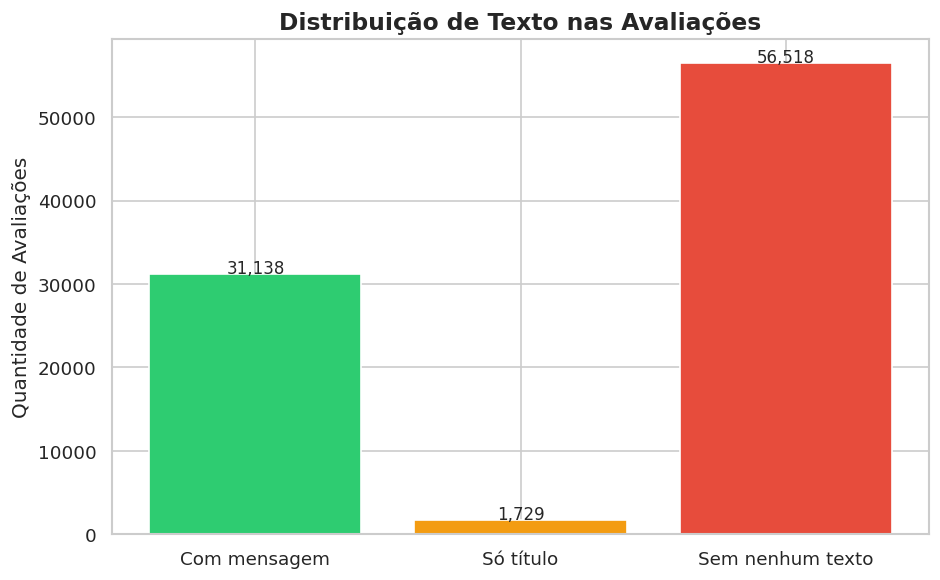

In [ ]:
# ============================================================ #
# Visualização da distribuição de texto nas avaliações
# ============================================================ #
categorias = ['Com mensagem', 'Só título', 'Sem nenhum texto']
valores    = [com_mensagem - com_ambos, so_titulo, sem_nenhum]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categorias, valores, color=['#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('Distribuição de Texto nas Avaliações', fontsize=14, fontweight='bold')
ax.set_ylabel('Quantidade de Avaliações')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================ #
# Concatenação de título + mensagem (padrão Notion)
# ============================================================ #
df_avaliacoes['review_comment_title']   = df_avaliacoes['review_comment_title'].fillna('')
df_avaliacoes['review_comment_message'] = df_avaliacoes['review_comment_message'].fillna('')

df_avaliacoes['review_text'] = (
    df_avaliacoes['review_comment_title'].str.strip() + ' ' +
    df_avaliacoes['review_comment_message'].str.strip()
)

# Remove espaços extras e converte vazio para NaN
df_avaliacoes['review_text'] = (
    df_avaliacoes['review_text']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace('', pd.NA)
)

# DataFrame limpo — apenas avaliações com algum texto
avaliacoes_limpo = (
    df_avaliacoes[['review_score', 'review_text', 'order_id',
                   'review_comment_title', 'review_comment_message',
                   'review_creation_date']]
    .dropna(subset=['review_text'])
    .reset_index(drop=True)
)

# Comprimento do texto
avaliacoes_limpo['review_text_length'] = avaliacoes_limpo['review_text'].str.len()

print(f'Avaliações com texto para análise: {len(avaliacoes_limpo):,}')
print(f'Avaliações removidas (sem texto):  {total - len(avaliacoes_limpo):,}')
display(avaliacoes_limpo.head())

Avaliações com texto para análise: 42,687
Avaliações removidas (sem texto):  56,537


,review_score,review_text,order_id,review_comment_title,review_comment_message,review_creation_date,review_text_length
0,5,Recebi bem antes do prazo estipulado.,658677c97b385a9be170737859d3511b,,Recebi bem antes do prazo estipulado.,2017-04-21,37
1,5,Parabéns lojas lannister adorei comprar pela I...,8e6bfb81e283fa7e4f11123a3fb894f1,,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,100
2,4,recomendo aparelho eficiente. no site a marca ...,b9bf720beb4ab3728760088589c62129,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,184
3,4,"Mas um pouco ,travando...pelo valor ta Boa.",9d6f15f95d01e79bd1349cc208361f09,,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",2018-02-16,43
4,5,"Super recomendo Vendedor confiável, produto ok...",e51478e7e277a83743b6f9991dbfa3fb,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23,72


In [ ]:
# ============================================================ #
# Padronização do texto — minúsculas e remoção de acentos
# ============================================================ #
avaliacoes_limpo['review_text'] = (
    avaliacoes_limpo['review_text']
    .str.lower()
    .apply(strip_accents)
)

print('✅ Texto padronizado.')
display(avaliacoes_limpo[['review_text', 'review_score']].head())

✅ Texto padronizado.


,review_text,review_score
0,recebi bem antes do prazo estipulado.,5
1,parabens lojas lannister adorei comprar pela i...,5
2,recomendo aparelho eficiente. no site a marca ...,4
3,"mas um pouco ,travando...pelo valor ta boa.",4
4,"super recomendo vendedor confiavel, produto ok...",5


In [ ]:
# ============================================================ #
# Salvar em Parquet — evita reprocessar nas próximas execuções
# ============================================================ #
avaliacoes_limpo.to_parquet('avaliacoes_limpo.parquet', index=False)
print('✅ DataFrame salvo em avaliacoes_limpo.parquet')

# Para recarregar sem reprocessar:
# avaliacoes_limpo = pd.read_parquet('avaliacoes_limpo.parquet')

✅ DataFrame salvo em avaliacoes_limpo.parquet


---
# Seção 4 — O Problema da Inconsistência

Antes de qualquer modelo, vamos mostrar que o problema existe. Há avaliações onde o texto escrito pelo cliente e a nota dada não contam a mesma história — e isso afeta diretamente a confiabilidade do marketplace.

In [ ]:
# ============================================================ #
# Casos extremos — notas altas com linguagem negativa
# ============================================================ #
palavras_negativas = ['pessimo', 'horrivel', 'terrivel', 'nao recomendo',
                       'quebrado', 'defeito', 'nao chegou', 'fraude', 'enganacao']

pattern_neg = '|'.join(palavras_negativas)

# Notas 4 ou 5 com texto claramente negativo
inconsistentes_positivos = avaliacoes_limpo[
    (avaliacoes_limpo['review_score'] >= 4) &
    (avaliacoes_limpo['review_text'].str.contains(pattern_neg, na=False))
]

# Notas 1 ou 2 com texto claramente positivo
palavras_positivas = ['otimo', 'excelente', 'perfeito', 'amei', 'recomendo',
                       'rapido', 'incrivel', 'maravilhoso']
pattern_pos = '|'.join(palavras_positivas)

inconsistentes_negativos = avaliacoes_limpo[
    (avaliacoes_limpo['review_score'] <= 2) &
    (avaliacoes_limpo['review_text'].str.contains(pattern_pos, na=False))
]

print(f'  Avaliações com nota alta (4-5) e texto negativo: {len(inconsistentes_positivos):,}')
print(f'  Avaliações com nota baixa (1-2) e texto positivo: {len(inconsistentes_negativos):,}')
print(f'\nTotal estimado de inconsistências detectadas por palavras-chave: '
      f'{len(inconsistentes_positivos) + len(inconsistentes_negativos):,}')
print(f'Isso representa {(len(inconsistentes_positivos)+len(inconsistentes_negativos))/len(avaliacoes_limpo)*100:.1f}% '
      f'das avaliações com texto')

⚠️  Avaliações com nota alta (4-5) e texto negativo: 196
⚠️  Avaliações com nota baixa (1-2) e texto positivo: 657

Total estimado de inconsistências detectadas por palavras-chave: 853
Isso representa 2.0% das avaliações com texto


In [ ]:
# ============================================================ #
# Exemplos reais de inconsistência — nota alta, texto negativo
# ============================================================ #
print('═'*60)
print('  EXEMPLOS: NOTA ALTA COM TEXTO NEGATIVO')
print('═'*60)
for _, row in inconsistentes_positivos[['review_text', 'review_score']].head(5).iterrows():
    print(f'\n  ⭐ Nota: {row["review_score"]} | Texto: "{row["review_text"]}"')

print('\n' + '═'*60)
print('  EXEMPLOS: NOTA BAIXA COM TEXTO POSITIVO')
print('═'*60)
for _, row in inconsistentes_negativos[['review_text', 'review_score']].head(5).iterrows():
    print(f'\n  ⭐ Nota: {row["review_score"]} | Texto: "{row["review_text"]}"')

════════════════════════════════════════════════════════════
  EXEMPLOS: NOTA ALTA COM TEXTO NEGATIVO
════════════════════════════════════════════════════════════

  ⭐ Nota: 4 | Texto: "4 se fosse vidro tinha quebrado; veio na caixa sem nenhuma protecao por dentro, a caixa estava muito amassada. desculpe.. mas gosto de comprar de vcs ."

  ⭐ Nota: 5 | Texto: "bom produto, veio sem neum defeito bom."

  ⭐ Nota: 4 | Texto: "embalagem inadequada tudo ocorreu beleza, so que a embalagem foi inadequada, nao ofereceu protecao ao item comprado , que possuiu um cd que chegou quebrado."

  ⭐ Nota: 5 | Texto: "vamos torcer para que seja o produto correto, pois o celular para o qual comprei esta capa nao chegou ainda. claramente, alguns parceiros sao mais confiaveis do que outros."

  ⭐ Nota: 4 | Texto: "um dos bonecos chegou com defeito"

════════════════════════════════════════════════════════════
  EXEMPLOS: NOTA BAIXA COM TEXTO POSITIVO
═════════════════════════════════════════════════════════

/tmp/ipykernel_2282/1441183977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=avaliacoes_limpo, x='review_score', palette='viridis', ax=ax)


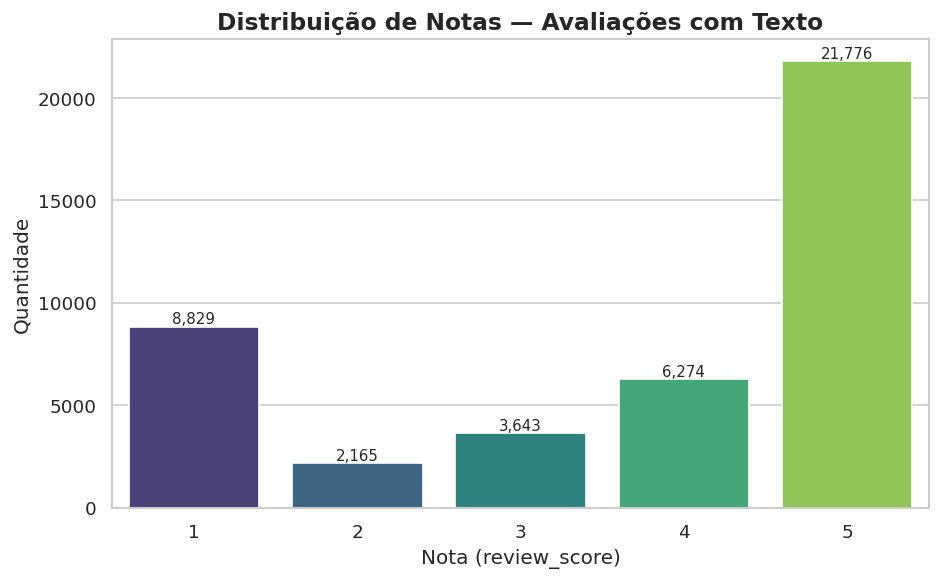

In [ ]:
# ============================================================ #
# Distribuição geral de review_score
# ============================================================ #
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=avaliacoes_limpo, x='review_score', palette='viridis', ax=ax)
ax.set_title('Distribuição de Notas — Avaliações com Texto', fontsize=14, fontweight='bold')
ax.set_xlabel('Nota (review_score)')
ax.set_ylabel('Quantidade')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
# Seção 5 — Análise de Sentimento

Com o problema mapeado, aplicamos três modelos de NLP para detectar o sentimento real de cada avaliação. Os modelos são progressivamente mais sofisticados: VADER (léxico em inglês), LeIA (léxico em PT-BR) e Transformers (modelo multilíngue baseado em BERT).

> **Nota:** Esta seção pode demorar vários minutos na primeira execução. Use o arquivo Parquet salvo na Seção 3 para recarregar os dados sem reprocessar.

In [ ]:
# ============================================================ #
# Inicialização dos modelos
# ============================================================ #
sid_vader = VaderAnalyzer()
sid_leia  = LeiaAnalyzer()
transformer_model = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment'
)

print(' Modelos inicializados.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Modelos inicializados.


In [ ]:
# ============================================================ #
# VADER — análise de sentimento
# ============================================================ #
def calcular_sentimento_vader(texto):
    if not isinstance(texto, str) or texto.strip() == '':
        return 0.0
    return sid_vader.polarity_scores(texto)['compound']

avaliacoes_limpo['pontuacao_vader'] = avaliacoes_limpo['review_text'].apply(calcular_sentimento_vader)
avaliacoes_limpo['classe_vader']    = avaliacoes_limpo['pontuacao_vader'].apply(classificacao)
avaliacoes_limpo['score_vader']     = avaliacoes_limpo['pontuacao_vader'].apply(classificacao_score)

print('✅ VADER concluído.')
display(avaliacoes_limpo[['review_text', 'review_score', 'pontuacao_vader', 'score_vader']].head())

✅ VADER concluído.


,review_text,review_score,pontuacao_vader,score_vader
0,recebi bem antes do prazo estipulado.,5,0.0000,3
1,parabens lojas lannister adorei comprar pela i...,5,0.0000,3
2,recomendo aparelho eficiente. no site a marca ...,4,-0.2960,2
3,"mas um pouco ,travando...pelo valor ta boa.",4,0.0000,3
4,"super recomendo vendedor confiavel, produto ok...",5,0.7269,5


In [ ]:
# ============================================================ #
# LeIA — análise de sentimento
# ============================================================ #
def calcular_sentimento_leia(texto):
    if not isinstance(texto, str) or texto.strip() == '':
        return 0.0
    return sid_leia.polarity_scores(texto)['compound']

avaliacoes_limpo['pontuacao_leia'] = avaliacoes_limpo['review_text'].apply(calcular_sentimento_leia)
avaliacoes_limpo['classe_leia']   = avaliacoes_limpo['pontuacao_leia'].apply(classificacao)
avaliacoes_limpo['score_leia']    = avaliacoes_limpo['pontuacao_leia'].apply(classificacao_score)

print('✅ LeIA concluído.')
display(avaliacoes_limpo[['review_text', 'review_score', 'pontuacao_leia', 'score_leia']].head())

✅ LeIA concluído.


,review_text,review_score,pontuacao_leia,score_leia
0,recebi bem antes do prazo estipulado.,5,0.2732,4
1,parabens lojas lannister adorei comprar pela i...,5,0.9413,5
2,recomendo aparelho eficiente. no site a marca ...,4,0.6486,5
3,"mas um pouco ,travando...pelo valor ta boa.",4,0.7264,5
4,"super recomendo vendedor confiavel, produto ok...",5,0.8979,5


In [ ]:
# ============================================================ #
# Transformers — análise em batches com barra de progresso
# ============================================================ #
review_texts_list = avaliacoes_limpo['review_text'].tolist()
batch_size = 256
resultados_pipeline = []

for i in tqdm(range(0, len(review_texts_list), batch_size), desc='Transformers — processando batches'):
    batch = review_texts_list[i:i + batch_size]
    resultados_pipeline.extend(transformer_model(batch, truncation=True))

scores_transformers = [get_sentiment_score_from_label(r['label']) for r in resultados_pipeline]

avaliacoes_limpo['pontuacao_transformers'] = scores_transformers
avaliacoes_limpo['classe_transformers']    = avaliacoes_limpo['pontuacao_transformers'].apply(classificacao)
avaliacoes_limpo['score_transformers']     = avaliacoes_limpo['pontuacao_transformers'].apply(classificacao_score)

print('✅ Transformers concluído.')
display(avaliacoes_limpo[['review_text', 'review_score', 'pontuacao_transformers', 'score_transformers']].head())

Transformers — processando batches:   0%|          | 0/167 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Transformers concluído.


,review_text,review_score,pontuacao_transformers,score_transformers
0,recebi bem antes do prazo estipulado.,5,0.0,3
1,parabens lojas lannister adorei comprar pela i...,5,1.0,5
2,recomendo aparelho eficiente. no site a marca ...,4,0.5,4
3,"mas um pouco ,travando...pelo valor ta boa.",4,0.0,3
4,"super recomendo vendedor confiavel, produto ok...",5,1.0,5


In [ ]:
# ============================================================ #
# Salvar resultado com scores de sentimento
# ============================================================ #
avaliacoes_limpo.to_parquet('avaliacoes_com_sentimento.parquet', index=False)
print('✅ Resultados salvos em avaliacoes_com_sentimento.parquet')

✅ Resultados salvos em avaliacoes_com_sentimento.parquet


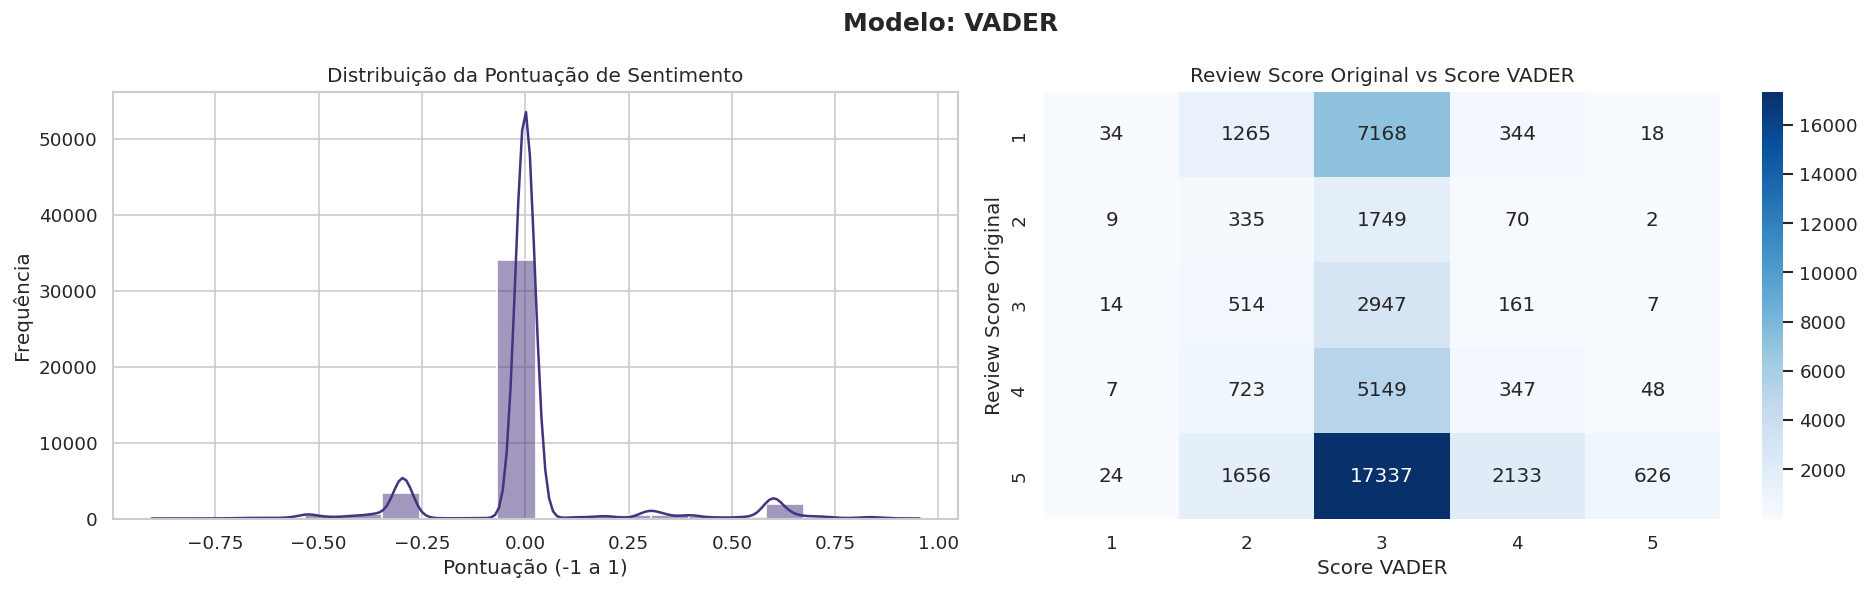

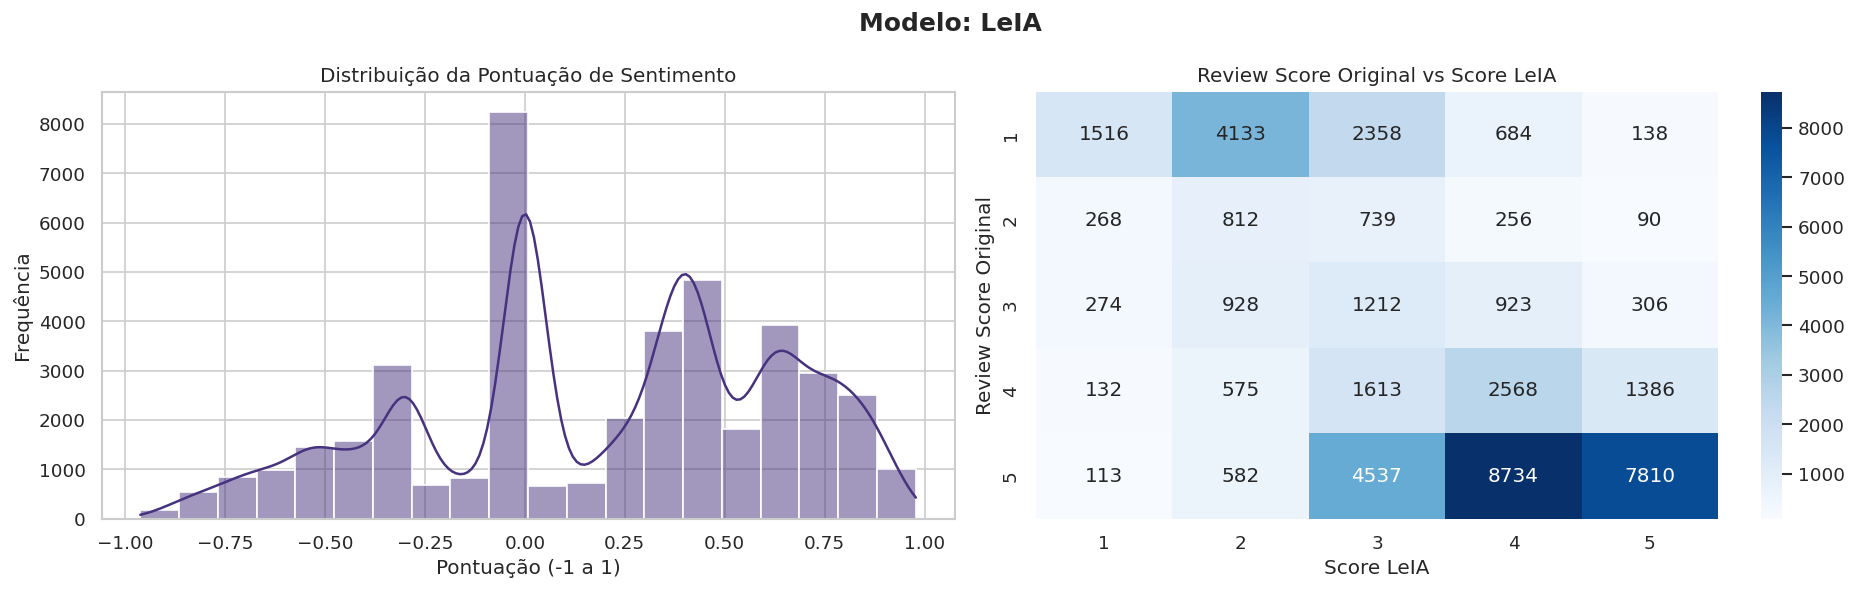

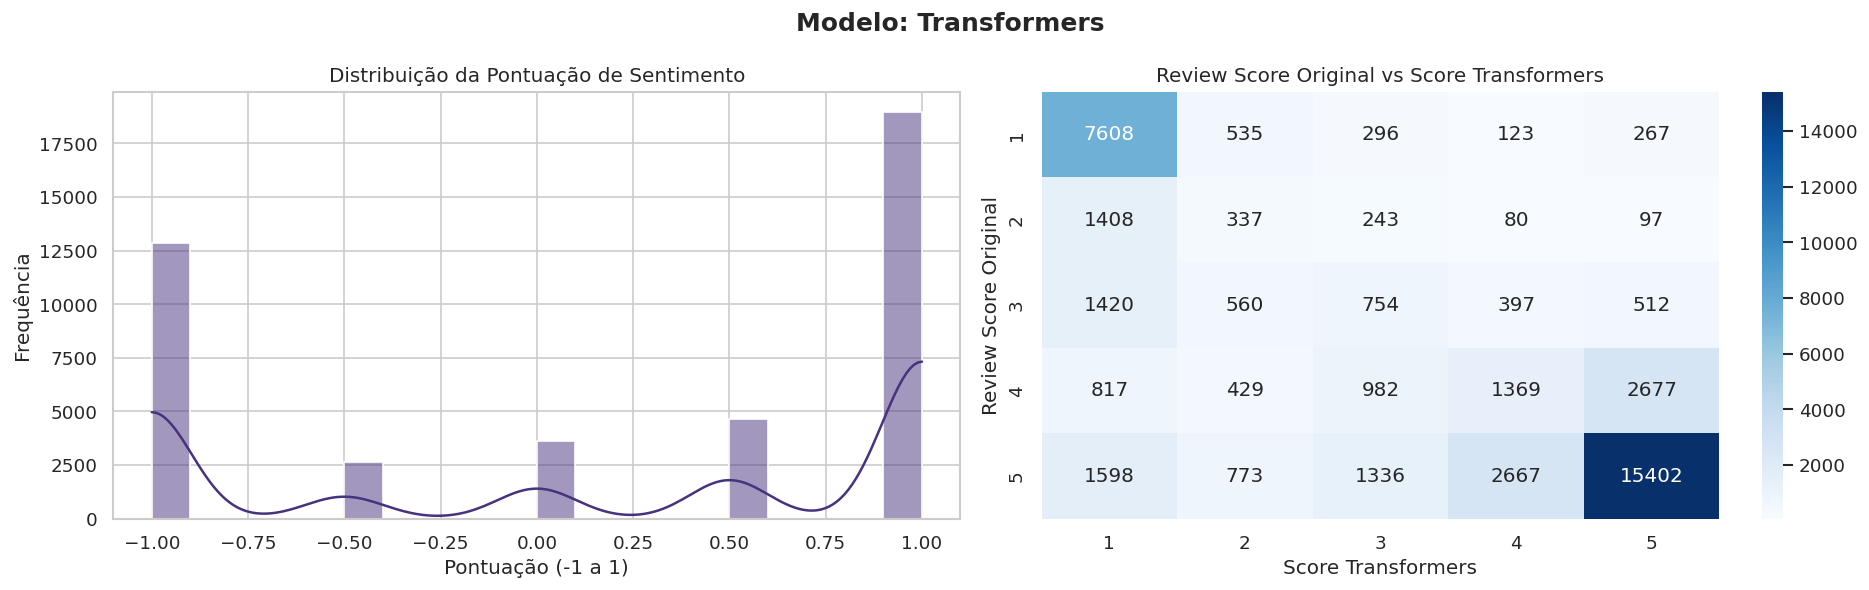

In [ ]:
# ============================================================ #
# Visualizações por modelo — histograma + heatmap de confusão
# ============================================================ #
modelos = [
    ('VADER',       'pontuacao_vader',       'score_vader'),
    ('LeIA',        'pontuacao_leia',        'score_leia'),
    ('Transformers','pontuacao_transformers','score_transformers'),
]

for nome, col_pont, col_score in modelos:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Modelo: {nome}', fontsize=15, fontweight='bold')

    # Histograma de distribuição
    sns.histplot(avaliacoes_limpo[col_pont], bins=20, kde=True, ax=axes[0])
    axes[0].set_title('Distribuição da Pontuação de Sentimento')
    axes[0].set_xlabel('Pontuação (-1 a 1)')
    axes[0].set_ylabel('Frequência')

    # Heatmap de confusão — score do modelo vs review_score original
    confusion = pd.crosstab(
        avaliacoes_limpo['review_score'],
        avaliacoes_limpo[col_score],
        rownames=['Review Score Original'],
        colnames=[f'Score {nome}']
    )
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title(f'Review Score Original vs Score {nome}')

    plt.tight_layout()
    plt.savefig("grafico.png", dpi=600, bbox_inches='tight')
    plt.show()

---
# Seção 6 — Comparação Entre Modelos

Com os três modelos rodados, podemos comparar diretamente seu desempenho. O objetivo é entender qual deles é mais confiável para o contexto de avaliações em português.

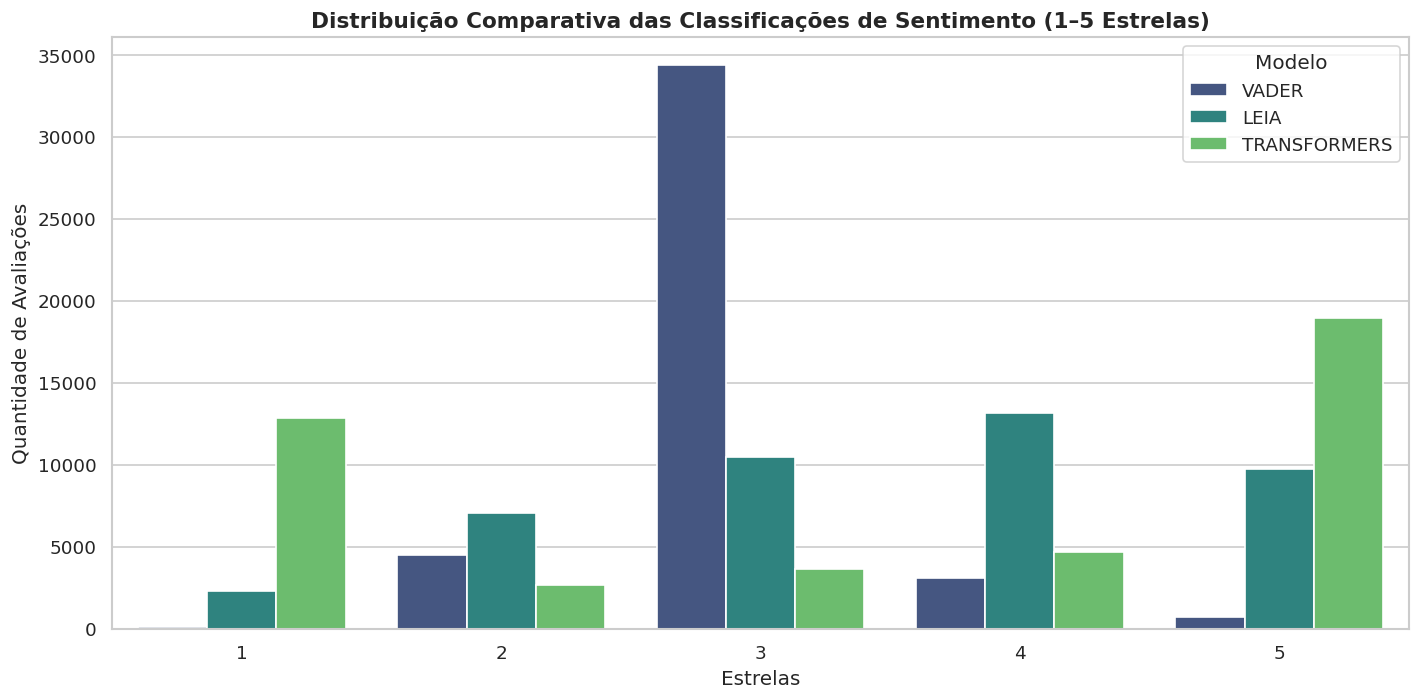

In [ ]:
# ============================================================ #
# Distribuição comparativa de classificações (1–5 estrelas)
# ============================================================ #
df_comp = avaliacoes_limpo[['score_vader', 'score_leia', 'score_transformers']].melt(
    var_name='Modelo', value_name='Classificação em Estrelas'
)
df_comp['Modelo'] = df_comp['Modelo'].str.replace('score_', '').str.upper()

fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df_comp, x='Classificação em Estrelas', hue='Modelo', palette='viridis', ax=ax)
ax.set_title('Distribuição Comparativa das Classificações de Sentimento (1–5 Estrelas)', fontsize=13, fontweight='bold')
ax.set_xlabel('Estrelas')
ax.set_ylabel('Quantidade de Avaliações')
plt.legend(title='Modelo')
plt.tight_layout()
plt.show()

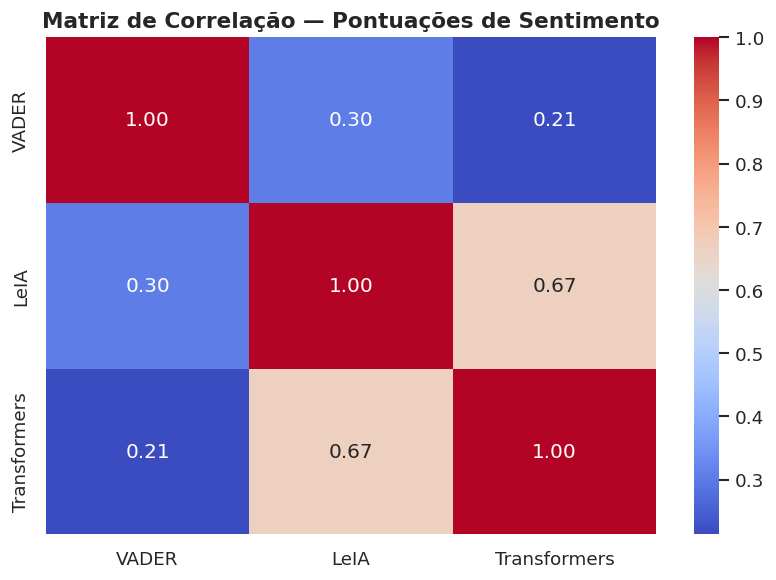

In [ ]:
# ============================================================ #
# Matriz de correlação entre as pontuações contínuas
# ============================================================ #
df_scores = avaliacoes_limpo[['pontuacao_vader', 'pontuacao_leia', 'pontuacao_transformers']]
corr_matrix = df_scores.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=ax,
            xticklabels=['VADER', 'LeIA', 'Transformers'],
            yticklabels=['VADER', 'LeIA', 'Transformers'])
ax.set_title('Matriz de Correlação — Pontuações de Sentimento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================ #
# Acurácia de cada modelo vs review_score original
# ============================================================ #
for nome, col_score in [('VADER', 'score_vader'), ('LeIA', 'score_leia'), ('Transformers', 'score_transformers')]:
    acerto = (avaliacoes_limpo['review_score'] == avaliacoes_limpo[col_score]).sum()
    pct    = acerto / len(avaliacoes_limpo) * 100
    print(f'{nome:<15} → acurácia direta: {acerto:,} / {len(avaliacoes_limpo):,} ({pct:.1f}%)')

VADER           → acurácia direta: 4,289 / 42,687 (10.0%)
LeIA            → acurácia direta: 13,918 / 42,687 (32.6%)
Transformers    → acurácia direta: 25,470 / 42,687 (59.7%)


---
# Seção 7 — Análise de Emojis e Wordcloud

Emojis são um vetor de ruído para modelos baseados em léxico. Aqui verificamos o impacto deles nas pontuações e exploramos quais palavras aparecem mais nas avaliações inconsistentes.

In [ ]:
# ============================================================ #
# Separando avaliações com e sem emojis
# ============================================================ #
# Aplicamos sobre o texto original (não padronizado) para preservar emojis
df_avaliacoes['tem_emoji'] = df_avaliacoes['review_comment_message'].apply(contains_emoji)

df_emoji    = avaliacoes_limpo[df_avaliacoes.loc[avaliacoes_limpo.index, 'tem_emoji'] == True]
df_sem_emoji= avaliacoes_limpo[df_avaliacoes.loc[avaliacoes_limpo.index, 'tem_emoji'] == False]

print(f'Avaliações com emoji:    {len(df_emoji):,}')
print(f'Avaliações sem emoji:    {len(df_sem_emoji):,}')

Avaliações com emoji:    135
Avaliações sem emoji:    42,552


/tmp/ipykernel_2282/2121140136.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_emoji, x='score_leia', palette='magma', ax=axes[0],
/tmp/ipykernel_2282/2121140136.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sem_emoji, x='score_leia', palette='viridis', ax=axes[1],


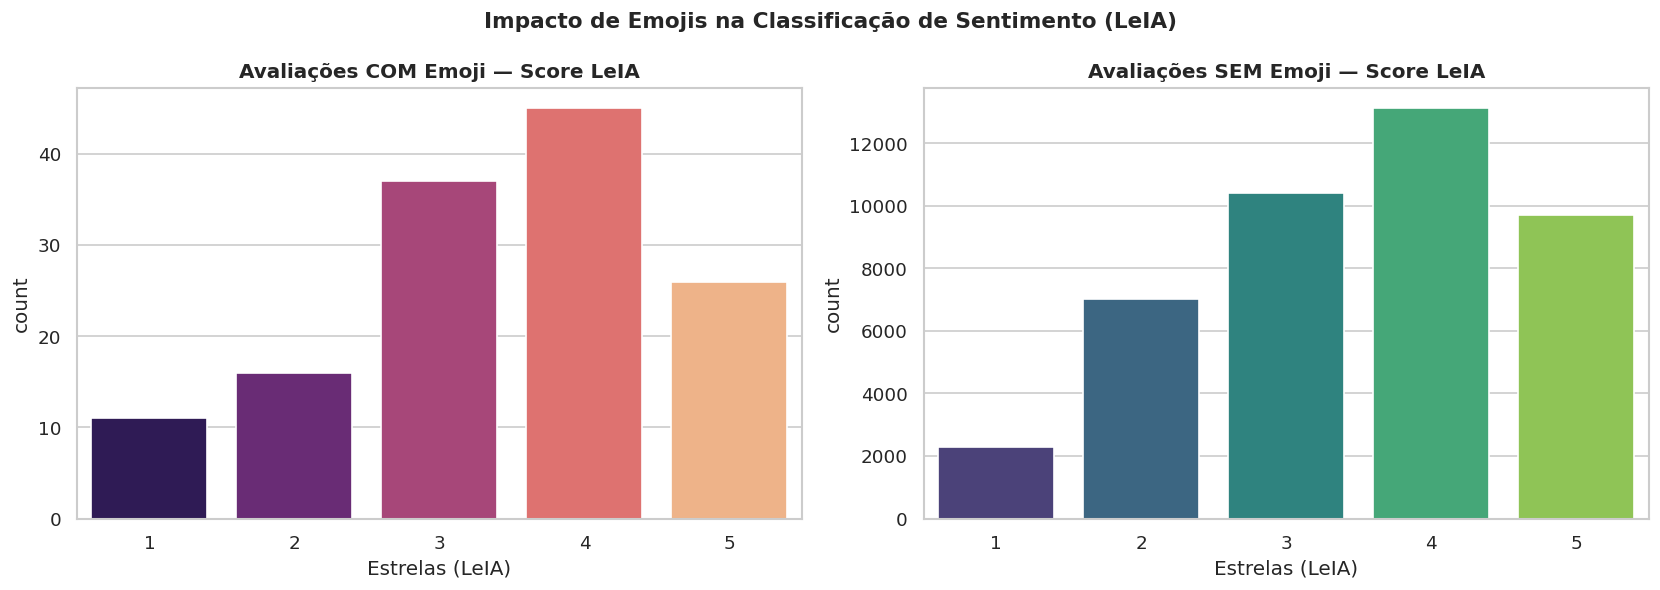

In [ ]:
# ============================================================ #
# Comparação de distribuição de scores — com vs sem emoji
# ============================================================ #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_emoji, x='score_leia', palette='magma', ax=axes[0],
              order=sorted(avaliacoes_limpo['score_leia'].unique()))
axes[0].set_title('Avaliações COM Emoji — Score LeIA', fontweight='bold')
axes[0].set_xlabel('Estrelas (LeIA)')

sns.countplot(data=df_sem_emoji, x='score_leia', palette='viridis', ax=axes[1],
              order=sorted(avaliacoes_limpo['score_leia'].unique()))
axes[1].set_title('Avaliações SEM Emoji — Score LeIA', fontweight='bold')
axes[1].set_xlabel('Estrelas (LeIA)')

plt.suptitle('Impacto de Emojis na Classificação de Sentimento (LeIA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2282/4166544836.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=avaliacoes_limpo, x='coerente_leia', y='review_text_length',


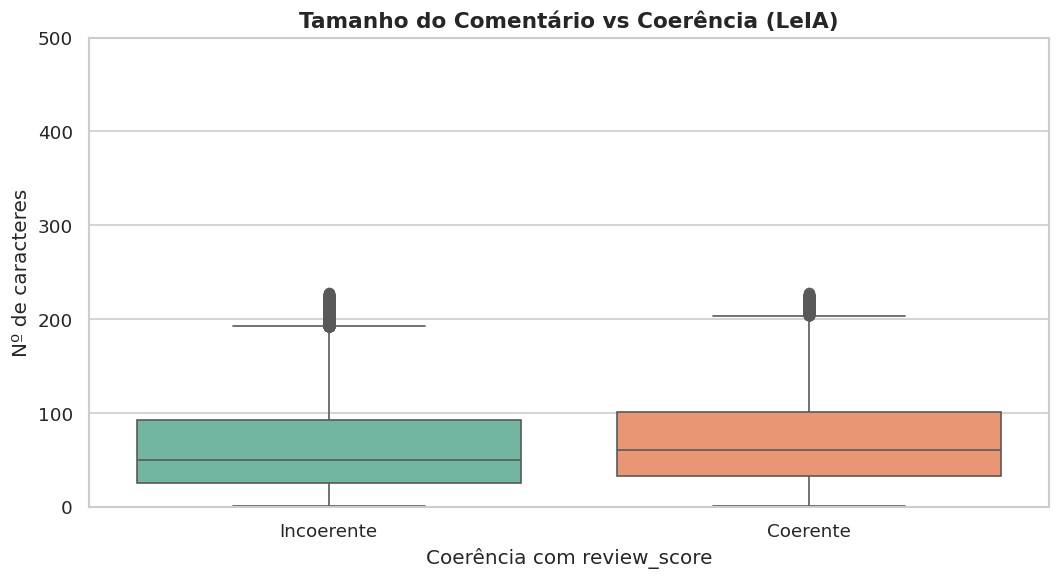

In [ ]:
# ============================================================ #
# Boxplot — tamanho do comentário vs acurácia dos modelos
# ============================================================ #
avaliacoes_limpo['coerente_leia'] = (
    avaliacoes_limpo['review_score'] == avaliacoes_limpo['score_leia']
).map({True: 'Coerente', False: 'Incoerente'})

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=avaliacoes_limpo, x='coerente_leia', y='review_text_length',
            palette='Set2', ax=ax)
ax.set_title('Tamanho do Comentário vs Coerência (LeIA)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coerência com review_score')
ax.set_ylabel('Nº de caracteres')
ax.set_ylim(0, 500)
plt.tight_layout()
plt.show()

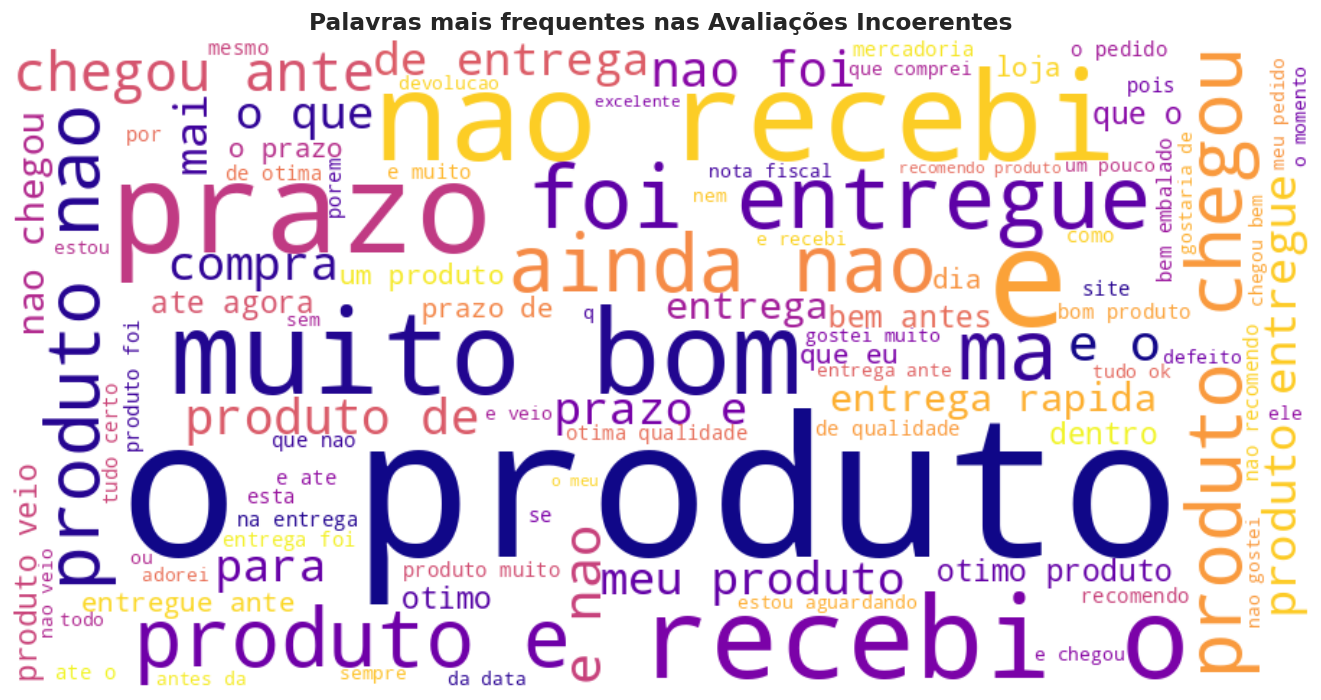

In [ ]:
# ============================================================ #
# Wordcloud — palavras mais frequentes nas avaliações inconsistentes
# ============================================================ #
incoerentes = avaliacoes_limpo[
    avaliacoes_limpo['review_score'] != avaliacoes_limpo['score_leia']
]

texto_incoerente = ' '.join(incoerentes['review_text'].dropna().tolist())

wc = WordCloud(
    width=900, height=450,
    background_color='white',
    colormap='plasma',
    max_words=100
).generate(texto_incoerente)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Palavras mais frequentes nas Avaliações Incoerentes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Seção 8 — Índice de Confiabilidade por Vendedor + Ordenação

Esta seção transforma a análise de texto em um insight de negócio. Cruzamos as inconsistências detectadas pelos modelos com os vendedores, gerando um **índice de confiabilidade** que indica quais vendedores têm maior discrepância entre a nota recebida e o sentimento real dos comentários.

Também comparamos o **Selection Sort** implementado manualmente com o `.sort_values()` nativo do pandas, evidenciando o trade-off entre compreensão pedagógica e eficiência computacional.

In [ ]:
# ============================================================ #
# Cruzando avaliações com vendedores via order_id
# ============================================================ #
df_av_vendedor = avaliacoes_limpo.merge(
    df_itens_pedidos[['order_id', 'seller_id']].drop_duplicates(),
    on='order_id',
    how='left'
).dropna(subset=['seller_id'])

print(f'Avaliações com seller_id identificado: {len(df_av_vendedor):,}')

Avaliações com seller_id identificado: 43,056


In [ ]:
# ============================================================ #
# Índice de Confiabilidade por Vendedor
# ============================================================ #
# Marca avaliações incoerentes (usando LeIA como referência principal)
df_av_vendedor['incoerente'] = (
    df_av_vendedor['review_score'] != df_av_vendedor['score_leia']
).astype(int)

indice_vendedor = df_av_vendedor.groupby('seller_id').agg(
    total_avaliacoes    = ('review_score', 'count'),
    nota_media_original = ('review_score', 'mean'),
    nota_media_leia     = ('score_leia',   'mean'),
    pct_incoerentes     = ('incoerente',   'mean')
).reset_index()

# Diferença entre nota real e nota pelo modelo
indice_vendedor['delta_nota'] = abs(
    indice_vendedor['nota_media_original'] - indice_vendedor['nota_media_leia']
)

# Índice final: quanto maior, menos confiável
indice_vendedor['indice_inconfiabilidade'] = (
    indice_vendedor['pct_incoerentes'] * 0.6 +
    (indice_vendedor['delta_nota'] / 4) * 0.4
).round(4)

# Apenas vendedores com volume mínimo relevante
indice_vendedor = indice_vendedor[indice_vendedor['total_avaliacoes'] >= 5]

print(f'Vendedores analisados (mín. 5 avaliações): {len(indice_vendedor):,}')
display(indice_vendedor.sort_values('indice_inconfiabilidade', ascending=False).head(10))

Vendedores analisados (mín. 5 avaliações): 1,205


,seller_id,total_avaliacoes,nota_media_original,nota_media_leia,pct_incoerentes,delta_nota,indice_inconfiabilidade
1849,b8114f2f589a6804810f04f99b36b498,5,4.600000,3.000000,1.0,1.600000,0.7600
430,2addf05f476d0637864454e93ba673d5,6,5.000000,3.500000,1.0,1.500000,0.7500
2475,f4a04f7be452aa3bb31760bf00055dd0,6,4.666667,3.166667,1.0,1.500000,0.7500
472,2f09f7d37a97956d11cc1a7cadd5262b,6,1.666667,3.000000,1.0,1.333333,0.7333
2307,e5475dcab1e07b63d7f6e902d8f5eda8,7,4.285714,3.142857,1.0,1.142857,0.7143
1346,82cb9f452fe8334df74b22d37824b431,5,5.000000,4.000000,1.0,1.000000,0.7000
2142,d354c38a7182125a748cb10474fe963b,8,4.250000,3.375000,1.0,0.875000,0.6875
1482,8fdca8e349553f99bc738833a62c8802,7,3.857143,3.000000,1.0,0.857143,0.6857
916,5a413ade68e8f8d93071a7f52a64cb9e,5,4.200000,3.400000,1.0,0.800000,0.6800
2223,db46ca7bce82b11f7e247539271fc390,5,4.200000,3.400000,1.0,0.800000,0.6800


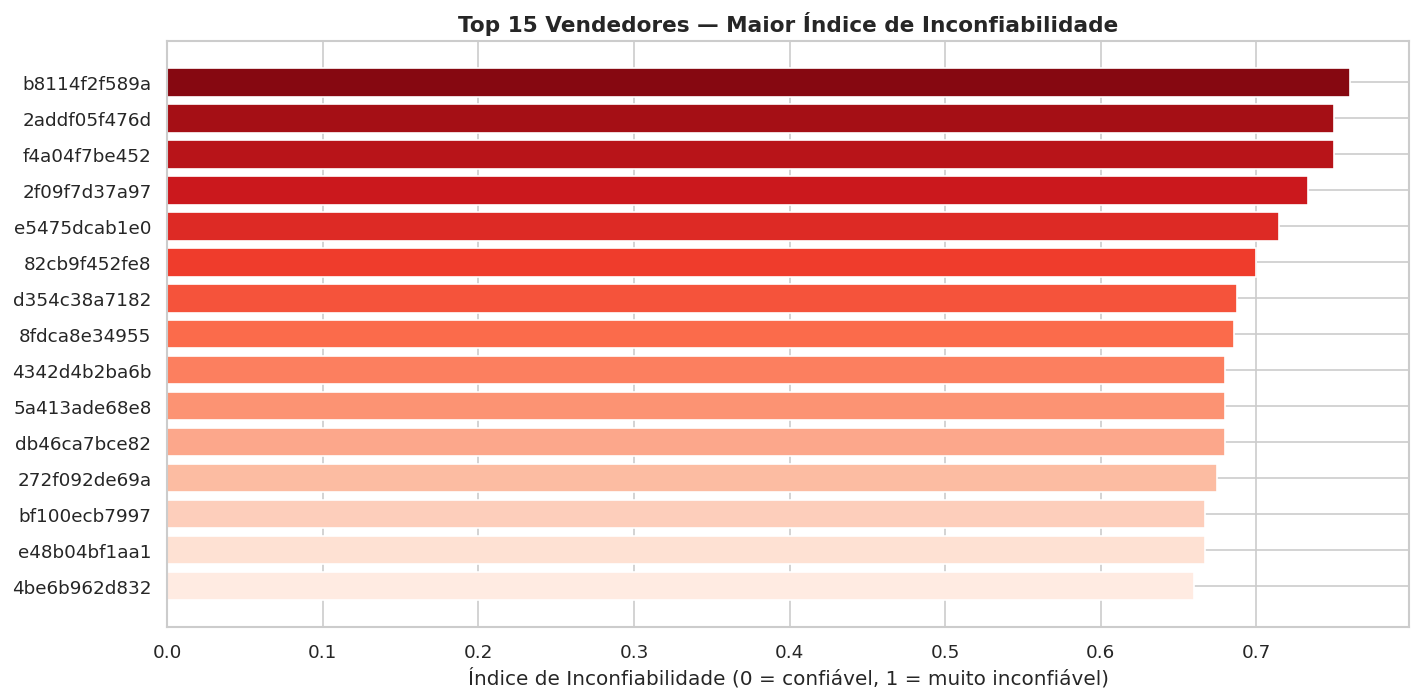

In [ ]:
# ============================================================ #
# Visualização — Top 15 vendedores com maior inconfiabilidade
# ============================================================ #
top15 = indice_vendedor.nlargest(15, 'indice_inconfiabilidade')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['seller_id'].str[:12], top15['indice_inconfiabilidade'],
               color=sns.color_palette('Reds_r', 15))
ax.set_title('Top 15 Vendedores — Maior Índice de Inconfiabilidade', fontsize=13, fontweight='bold')
ax.set_xlabel('Índice de Inconfiabilidade (0 = confiável, 1 = muito inconfiável)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================ #
# Ordenação com Selection Sort — comentários por pontuação
# ============================================================ #

# Amostra para o Selection Sort (O(n²) — inviável no dataset completo)
amostra = avaliacoes_limpo[['review_text', 'pontuacao_leia']].dropna().head(500)

data_para_ordenar = list(zip(amostra['pontuacao_leia'], amostra['review_text']))

# ---- Selection Sort ----
inicio_ss = time.time()
ordenado_ss = selection_sort_by_value_descending(data_para_ordenar)
tempo_ss = time.time() - inicio_ss

# ---- sort_values (pandas) ----
inicio_pd = time.time()
ordenado_pd = amostra.sort_values('pontuacao_leia', ascending=False)
tempo_pd = time.time() - inicio_pd

print(f'Selection Sort — tempo: {tempo_ss:.4f}s  (amostra: {len(amostra)} registros)')
print(f'pandas sort_values    — tempo: {tempo_pd:.6f}s')
print(f'\nDiferença de velocidade: {tempo_ss/max(tempo_pd,0.0001):.0f}x mais lento com Selection Sort')
print('\n→ O Selection Sort é útil para compreender o algoritmo, mas o pandas é a escolha certa em produção.')

Selection Sort — tempo: 0.0065s  (amostra: 500 registros)
pandas sort_values    — tempo: 0.000378s

Diferença de velocidade: 17x mais lento com Selection Sort

→ O Selection Sort é útil para compreender o algoritmo, mas o pandas é a escolha certa em produção.


In [ ]:
# ============================================================ #
# Comentários mais positivos e mais negativos (LeIA)
# ============================================================ #
print(' TOP 5 COMENTÁRIOS MAIS POSITIVOS (LeIA):')
print('─'*60)
for score, texto in ordenado_ss[:5]:
    print(f'  [{score:.2f}] {texto[:120]}')

print(f'\n TOP 5 COMENTÁRIOS MAIS NEGATIVOS (LeIA):')
print('─'*60)
for score, texto in ordenado_ss[-5:]:
    print(f'  [{score:.2f}] {texto[:120]}')

📈 TOP 5 COMENTÁRIOS MAIS POSITIVOS (LeIA):
────────────────────────────────────────────────────────────
  [0.95] a bolsa termica alem de linda e super espacosa . produto de acordo com o anunciado e a entrega super rapida , entregou b
  [0.95] super recomendo agradeco muito, pois recebi o produto correto conforme encontrado no site, a entrega foi super rapida. f
  [0.94] parabens lojas lannister adorei comprar pela internet seguro e pratico parabens a todos feliz pascoa
  [0.94] maravilhoso! to completamente apaixonada, loja super responsavel e confiavel!
  [0.92] muito bom o produto muito bom o produto, melhor que esperava e foi entregue no prazo, gostei bastante.

📉 TOP 5 COMENTÁRIOS MAIS NEGATIVOS (LeIA):
────────────────────────────────────────────────────────────
  [-0.80] produto muito inferior, mal acabado.
  [-0.81] produto mais que passou do prazo de entregar, tento resolver o problema com a empresa e nao consigo falar com ninguem. t
  [-0.86] produto pessimo produto ja chegou 

---
# Conclusão

## O que foi feito

Este projeto analisou um banco de dados real de e-commerce com 9 tabelas, focando na **relação entre comentários e notas de avaliação**. Passou- se por diagnóstico, limpeza, análise de sentimento com três modelos distintos e geração de insights por vendedor.

**Sobre os dados:**
- Uma parcela significativa das avaliações não possui texto, o que limita a análise de sentimento.
- A concatenação de título + mensagem recupera avaliações que seriam descartadas.
- Emojis introduzem ruído nos modelos de sentimento.

- **VADER** apresenta a menor precisão para português — era esperado, por ser um modelo treinado em inglês.
- **LeIA** melhora consideravelmente o desempenho por ser adaptado ao PT-BR.
- **Transformers (nlptown/bert)** oferece o melhor resultado geral, com maior capacidade de captura de contexto, ao custo de maior tempo de processamento.

- O índice de inconfiabilidade revela vendedores com nota alta mas sentimento real dos comentários divergente, um sinal de alerta.

## Limitações

- A precisão dos modelos é estimada pela comparação com `review_score`.
- Sarcasmo e a linguagem informal continuam sendo desafios para todos os modelos testados.

## Sugestão para melhoria

Uma ideia para este problema, seria uma implementação de um sistema de avaliação pré definido, verificou - se, além dos comentários divergentes do score, que muitos comentários negativos, tem relação com a entrega do produto, sendo assim, seria viável a separação da avaliação em duas partes, Produto e Entrega. Onde teria comentários ja definidos como:

**Produto**
- Muito negativo - **"Com defeito."**
- Negativo - **"Ruim."**
- Neutro - **"Neutro."**
- Bom - **"Bom."**
- Muito Bom - **"Excelente!"**

**Entrega**
- Muito negativo - **"Não chegou."**
- Negativo - **"Ruim."**
- Neutro - **"Neutro."**
- Bom - **"Bom."**
- Muito Bom - **"Chegou bem embalado!"**

Com comentários pré definidos, seria possível evitar avaliações sem comentarios e também comentários que não condizem com o score. E com a separação da avaliação da entrega, irá evitar comentários em que o produto é positivo, porém é mal avaliado, devido a problemas externos de entrega.
